# Tutorial — Simple Birth-Death with EvoSeer

This notebook is a minimal end-to-end walkthrough of the EvoSeer engine.

**Goal:** reproduce the classical stochastic birth-death process where each cell has a fixed birth rate `b` and a population-dependent death rate `d·N`. We verify that the agent-based Gillespie simulation matches the expected dynamics.

**Reference (scalar ODE version):**
```
b = 1,  d = 0.01
λ = b + d·N
P(birth) = b / λ,  P(death) = d·N / λ
```

**What you will learn:**
1. How to define mutations in the `MutationStore`
2. How to write a `FeaturePlugin` (only `compute_score` is required)
3. How to assemble and run the engine
4. How to visualise single and multi-run trajectories


## Step 1 — Define mutations

In EvoSeer every cell carries a set of **mutation IDs**. Biological properties (birth rate, death rate, pathway membership…) are not stored on the cell directly — they live in the `MutationStore` as `MutationRecord` objects.

Here we create a single mutation that encodes `b=1` and `d=0.01`. Plugins will look these values up at score-computation time via `self._store.get(mutation_id)`.


## Step 2 — Write plugins

A `FeaturePlugin` maps a cell's mutation set to a numeric score used by the rate function.

**Minimal contract:** only `compute_score` is abstract. The base class provides:
- `self._store` — the mutation store, injected automatically
- `self.get_extra(record, key)` — validated access to `MutationRecord.extra` with a clear error if the key is missing
- Default `init_state` (returns a plain `PluginState`) and `on_division` (child inherits parent score, no dirty flag)

For this tutorial two plugins suffice: one for birth, one for death. Each sums the relevant field across the cell's mutations.

> Note: plugin *classes* are defined before the store is passed to them. The store is injected at instantiation (in Step 3), not at class definition time.


In [2]:
from evoseer.core.cell import CellState
from evoseer.core.context import SimContext
from evoseer.plugins.base import FeaturePlugin


class BirthRatePlugin(FeaturePlugin):
    """Score = sum of 'b' values across all mutations the cell carries."""
    name = "birth_rate"
    involved_pathways = []

    def compute_score(self, cell_state: CellState, ctx: SimContext) -> float:
        return sum(
            self.get_extra(self._store.get(mid), 'b')
            for mid in cell_state.mutations
        )


class DeathRatePlugin(FeaturePlugin):
    """Score = sum of 'd' values across all mutations the cell carries."""
    name = "death_rate"
    involved_pathways = []

    def compute_score(self, cell_state: CellState, ctx: SimContext) -> float:
        return sum(
            self.get_extra(self._store.get(mid), 'd')
            for mid in cell_state.mutations
        )


In [3]:
from evoseer.services.mutation_store import InMemoryMutationStore, MutationRecord

store = InMemoryMutationStore()
store.add_mutation(MutationRecord(
    mutation_id=1,
    gene_name="GENE",
    pathways=[],
    is_driver=False,
    extra={"b": 1, "d": 0.01},
))


## Step 3 — Assemble the engine

The engine needs four components:

| Component | Role |
|---|---|
| `plugins` | dict of `FeaturePlugin` instances, each with a `PluginConfig` |
| `RateFunction` | maps plugin scores → (birth_rate, death_rate) per cell |
| `MutationGenerator` | decides how many/which mutations appear at each division |
| `Recorder` | logs events and periodic population snapshots |

**Rate function:** `WeightedSumRate` computes:
```
birth = Σ score_i · weight · N^alpha    (category="proliferative")
death = Σ score_i · weight · N^alpha    (category="deleterious")
```
Setting `alpha=1` on the death plugin gives the `d·N` density dependence we want.

**Mutations disabled:** `NoMutationGenerator` always returns `[]` — cells keep their founder mutation throughout the simulation.


In [4]:
from typing import Any

from evoseer.core.config import PluginConfig, RateFunctionConfig, RecorderConfig, SimulationConfig
from evoseer.engine.gillespie import GillespieEngine
from evoseer.rate_functions.weighted_sum import WeightedSumRate
from evoseer.recording.recorder import Recorder
from evoseer.services.mutation_generator import MutationGenerator
from evoseer.services.mutation_store import MutationStore


class NoMutationGenerator(MutationGenerator):
    """Generator that never produces new mutations — cells keep their founder state."""
    name = "none"

    def __init__(self, store: MutationStore, params: dict[str, Any]) -> None:
        pass

    def generate(self, mu: float) -> list[int]:
        return []


# --- plugins ---
plugins = {
    "birth_rate": BirthRatePlugin(params={}, store=store),
    "death_rate": DeathRatePlugin(params={}, store=store),
}

plugin_configs = {
    "birth_rate": PluginConfig(
        name="birth_rate", plugin_type="birth_rate",
        target="rate_function", category="proliferative",
        weight=1.0, alpha=0.0,
    ),
    "death_rate": PluginConfig(
        name="death_rate", plugin_type="death_rate",
        target="rate_function", category="deleterious",
        weight=1.0, alpha=1.0,   # d·N  density dependence
    ),
}

# --- rate function ---
rate_fn = WeightedSumRate(RateFunctionConfig(
    function_type="weighted_sum",
    baseline_birth_rate=0.0,
    baseline_death_rate=0.0,
))


## Step 4 — Run a single simulation

`make_founder_cell()` creates a cell with all plugins initialised but **no mutations**. We manually seed it with the store's only mutation so it has `b=1` and `d=0.01` from the start.

Snapshots are recorded every `snapshot_interval` steps and contain `(step, t, n_alive)`.


In [ ]:
import matplotlib.pyplot as plt

engine = GillespieEngine(
    plugins=plugins,
    plugin_configs=plugin_configs,
    rate_function=rate_fn,
    mutation_generator=NoMutationGenerator(store=store, params={}),
    store=store,
    recorder=Recorder(snapshot_interval=1, dump_final_state=False),  # fresh recorder
    config=SimulationConfig(max_steps=2500, max_time=1e9, max_cells=10_000, seed=42),
)

founder = engine.make_founder_cell()
founder.state.mutations = set(store.all_ids())
result = engine.run([founder])

print(f"Stop reason: {result.stop_reason}  |  snapshots: {len(result.snapshots)}")

steps   = [s.step    for s in result.snapshots]
times   = [s.t       for s in result.snapshots]
n_alive = [s.n_alive for s in result.snapshots]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(steps, n_alive)
ax1.set_xlabel("Gillespie step"); ax1.set_ylabel("N"); ax1.set_title("N vs step")
ax2.plot(times, n_alive)
ax2.set_xlabel("Time"); ax2.set_ylabel("N"); ax2.set_title("N vs time")
plt.tight_layout(); plt.show()


## Step 5 — 100 stochastic runs

Each run gets a fresh engine (new `Recorder`, new `seed`). We overlay all trajectories in light blue and the **mean over active runs** in red.

Two averaging strategies:
- **vs step** — runs are naturally aligned (same snapshot interval), extinct runs are padded with 0
- **vs time** — each trajectory is interpolated onto a shared time grid; only runs still alive at time `t` contribute to the mean


  0%|          | 0/10 [00:00<?, ?it/s]

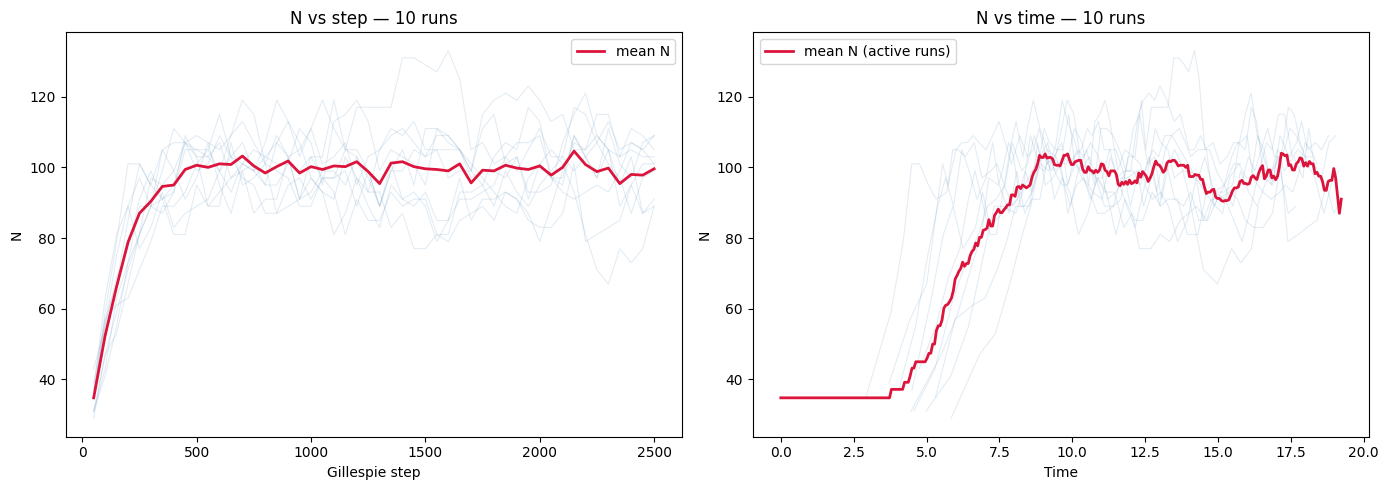

Stop reasons: {'max_steps': 10}


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

N_RUNS = 10

def run_once(seed: int):
    rec = Recorder(snapshot_interval=50, dump_final_state=False)
    cfg = SimulationConfig(max_steps=2500, max_time=1e9, max_cells=10_000, seed=seed)
    eng = GillespieEngine(
        plugins=plugins, plugin_configs=plugin_configs,
        rate_function=rate_fn, mutation_generator=generator,
        store=store, recorder=rec, config=cfg,
    )
    f = eng.make_founder_cell()
    f.state.mutations = set(store.all_ids())
    return eng.run([f])

results_100 = [run_once(seed=i) for i in tqdm(range(N_RUNS))]

all_steps = [[s.step    for s in r.snapshots] for r in results_100]
all_times = [[s.t       for s in r.snapshots] for r in results_100]
all_n     = [[s.n_alive for s in r.snapshots] for r in results_100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for steps_i, times_i, n_i in zip(all_steps, all_times, all_n):
    ax1.plot(steps_i, n_i, color="steelblue", alpha=0.15, linewidth=0.8)
    ax2.plot(times_i, n_i, color="steelblue", alpha=0.15, linewidth=0.8)

# mean vs step (pad extinct runs with 0)
max_len   = max(len(s) for s in all_steps)
step_grid = all_steps[int(np.argmax([len(s) for s in all_steps]))]
n_matrix  = np.zeros((N_RUNS, max_len))
for i, n in enumerate(all_n):
    n_matrix[i, :len(n)] = n
ax1.plot(step_grid, n_matrix.mean(axis=0), color="crimson", linewidth=2, label="mean N")
ax1.set_xlabel("Gillespie step"); ax1.set_ylabel("N"); ax1.set_title(f"N vs step — {N_RUNS} runs"); ax1.legend()

# mean vs time (only active runs at each t)
t_max  = max(t[-1] for t in all_times if t)
t_grid = np.linspace(0, t_max, 300)
mean_t, mean_n_t = [], []
for t_val in t_grid:
    vals = [
        n_i[max(0, np.searchsorted(times_i, t_val, side="right") - 1)]
        for times_i, n_i in zip(all_times, all_n)
        if times_i and t_val <= times_i[-1]
    ]
    if vals:
        mean_t.append(t_val); mean_n_t.append(np.mean(vals))
ax2.plot(mean_t, mean_n_t, color="crimson", linewidth=2, label="mean N (active runs)")
ax2.set_xlabel("Time"); ax2.set_ylabel("N"); ax2.set_title(f"N vs time — {N_RUNS} runs"); ax2.legend()

plt.tight_layout(); plt.show()

stop_reasons = {}
for r in results_100:
    stop_reasons[r.stop_reason] = stop_reasons.get(r.stop_reason, 0) + 1
print("Stop reasons:", stop_reasons)


You can easily change the simulation by changing one of the module. I.e change the rate function 

Stop reason: max_steps  |  snapshots: 2500


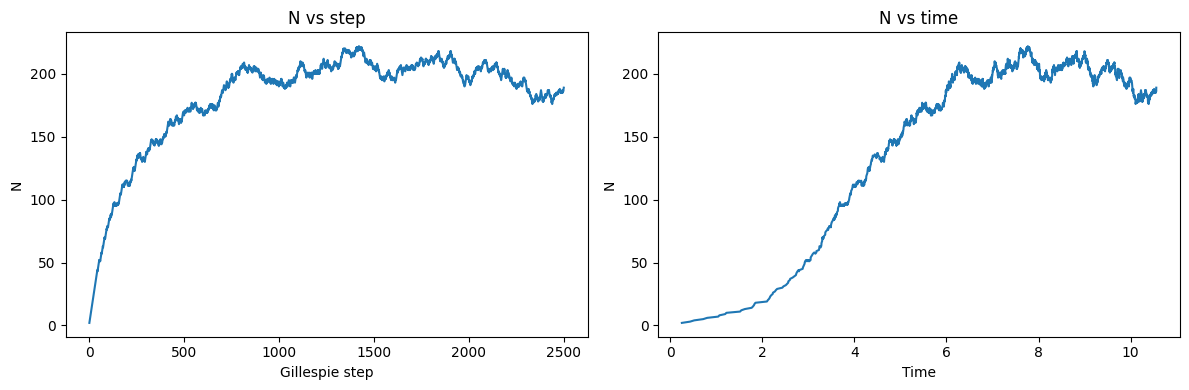

In [16]:
from evoseer.rate_functions.base import RateFunction

class NewRateFunction(RateFunction):
    def compute_rates(
        self,
        scores: dict[str, float],
        plugin_configs: dict[str, PluginConfig],
        N: int,
    ) -> tuple[float, float]:
        birth = scores["birth_rate"]
        death = scores["death_rate"] * plugin_configs.get("death_rate").alpha * N

        return max(0.0, birth), max(0.0, death)

rate_fn = NewRateFunction(RateFunctionConfig())

plugin_configs = {
    "birth_rate": PluginConfig(
        name="birth_rate", plugin_type="birth_rate",
        target="rate_function", category="proliferative",
        weight=1.0, alpha=0.0,
    ),
    "death_rate": PluginConfig(
        name="death_rate", plugin_type="death_rate",
        target="rate_function", category="deleterious",
        weight=1.0, alpha=0.5,
    ),
}

engine = GillespieEngine(
    plugins=plugins,
    plugin_configs=plugin_configs,
    rate_function=rate_fn,
    mutation_generator=NoMutationGenerator(store=store, params={}),
    store=store,
    recorder=Recorder(snapshot_interval=1, dump_final_state=False),  # fresh recorder
    config=SimulationConfig(max_steps=2500, max_time=1e9, max_cells=10_000, seed=42),
)

founder = engine.make_founder_cell()
founder.state.mutations = set(store.all_ids())
result = engine.run([founder])

print(f"Stop reason: {result.stop_reason}  |  snapshots: {len(result.snapshots)}")

steps   = [s.step    for s in result.snapshots]
times   = [s.t       for s in result.snapshots]
n_alive = [s.n_alive for s in result.snapshots]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(steps, n_alive)
ax1.set_xlabel("Gillespie step"); ax1.set_ylabel("N"); ax1.set_title("N vs step")
ax2.plot(times, n_alive)
ax2.set_xlabel("Time"); ax2.set_ylabel("N"); ax2.set_title("N vs time")
plt.tight_layout(); plt.show()
